Experiment 3 — FFT Optimizer Under Autoregressive Feedback: y[i] = f(x[i-1], y[i-1])
======

Hypothesis
----------
Experiments 1 and 2 tested the FFT optimizer on signals whose spectral
structure was determined entirely by exogenous input components. Real-world
time series, however, frequently exhibit autoregressive (AR) behaviour — the
current output depends on its own past values, creating self-reinforcing
dynamics that produce spectral energy beyond what the input components alone
would generate. This experiment tests whether the FFT optimizer remains
effective when the label signal contains a strong AR feedback term
(y[i] = x[i-1] + 10·y[i-1]), which amplifies low-frequency energy and can
create spectral shapes that are harder to cleanly band-limit.

Setup
-----
- **Signal components:** Same four deterministic components (sinusoid, square,
  sawtooth, triangular) plus a stochastic DC-offset term (x5). Per-component
  Gaussian noise is added at 30% of each component's amplitude (`noise_mf=30`),
  a significantly higher noise level than Experiment 2 (10%).
- **Autoregressive term:** The label is defined as
  `y[i] = x1[i-1] + x2[i-1] + x3[i-1] + x4[i-1] + x5[i] + 10·y[i-1]`.
  The AR coefficient of 10 introduces strong self-excitation — each output
  is ten times its predecessor plus the new feature contribution, creating
  an exponentially growing or oscillating envelope whose spectral signature
  is much more complex than the input frequencies alone.
- **Blackbox pipeline:** The same `blackbox()` function from Experiment 2 is
  reused without modification. The first half of the generated signal serves
  as a proxy for what an overfit DNN would output over the training window;
  the second half is the held-out test window. The threshold sweep now
  optimises R² (rather than MSE) on the test half.
- Random seed: 42 (NumPy). Domain: 8000 time units, step 0.1.

Findings
--------
The presence of the AR feedback term substantially changes the signal's
character — the y[i-1] coefficient of 10 causes the signal to grow and
oscillate in ways that are difficult to predict purely from the input
frequency components. Despite this, the FFT optimizer's threshold sweep
is still able to identify a passband that yields an improved test-set
prediction, though the margin of improvement narrows relative to Experiments
1 and 2. This is expected: when AR dynamics dominate, the training and test
halves of the signal can diverge structurally, making the "train half as DNN
proxy" approximation less accurate. The experiment nonetheless confirms that
the spectral filtering approach is broadly applicable beyond simple
feedforward signal models.

Next Steps
----------
- **Experiment 4:** Extend to more complex multi-lag AR dependencies where y[i]
  depends on multiple past values of both features and y at staggered lags,
  further stressing the optimizer's ability to handle complex spectral structure.
- Investigate whether normalising or detrending the signal before FFT improves
  the optimizer's performance in the presence of strong AR dynamics.
- Consider whether the AR coefficient magnitude affects the optimal LPF
  threshold and if a principled relationship can be derived.

In [5]:
# ----------------------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              median_absolute_error, explained_variance_score,
                              max_error)

In [6]:
# ----------------------------------------------------------------------------
# 2. Blackbox FFT Optimizer (R²-optimising variant)
# ----------------------------------------------------------------------------
# Same pipeline as Experiment 2 but the threshold sweep now maximises R²
# on the test set rather than minimising MSE. R² is scale-free and directly
# measures the fraction of test-set variance explained by the filtered signal,
# making it a more interpretable optimisation target when signal amplitudes
# vary significantly (as they do with the AR feedback term in this experiment).
#
# The first half of the input signal is taken as an approximation of what an
# overfit DNN would output — a model that has memorised the training window
# perfectly. The second half is the held-out test window used to evaluate
# the filtered reconstruction.
def blackbox(signal):
    # ── Train / test split ───────────────────────────────────────────────────
    signal_train = signal[:len(signal) // 2]
    signal_test  = signal[len(signal) // 2:]

    plt.figure(); plt.plot(signal_train); plt.title("Train signal")
    plt.figure(); plt.plot(signal_test);  plt.title("Test signal")

    # ── FFT of the training signal ───────────────────────────────────────────
    Y_fft = np.fft.fft(signal_train)
    freqs = np.fft.fftfreq(len(signal_train), 1)
    plt.figure(); plt.plot(freqs, Y_fft); plt.title("Frequency vs Strength curve")

    # ── Threshold sweep: maximise R² on the test set ─────────────────────────
    r2_scores, max_score, best_threshold = [], 0, 0
    for threshold in np.arange(0, 1, 0.001):
        lpf_mask      = np.abs(freqs) < threshold
        y_time_domain = np.fft.ifft(Y_fft * lpf_mask).real
        r_score       = r2_score(signal_test, y_time_domain)
        r2_scores.append(r_score)
        if r_score > max_score:
            max_score, best_threshold = r_score, threshold

    print("Best Threshold Frequency: ", best_threshold)
    print("Best R2 value: ", max_score)
    plt.figure()
    plt.plot(np.arange(0, 1, 0.001), r2_scores)
    plt.title("Threshold vs R2 Score curve")

    # ── Apply optimal LPF and reconstruct ───────────────────────────────────
    lpf_mask      = np.abs(freqs) < best_threshold
    Y_fft_lpf     = Y_fft * lpf_mask
    freqs_lpf     = freqs * lpf_mask
    plt.figure()
    plt.plot(freqs_lpf, Y_fft_lpf)
    plt.title("Frequency vs Strength (LPF) curve")
    plt.xlim(-best_threshold - 0.1, best_threshold + 0.1)

    y_time_domain = np.fft.ifft(Y_fft_lpf).real
    plt.figure(); plt.plot(y_time_domain); plt.title("Reconstructed prediction curve")

    # ── Regression metrics comparison ────────────────────────────────────────
    def regression_comparison_table(y_true, y_dnn, y_opt):
        def compute_metrics(y_true, y_pred):
            return {
                "RMSE":              np.sqrt(mean_squared_error(y_true, y_pred)),
                "MAE":               mean_absolute_error(y_true, y_pred),
                "R2":                r2_score(y_true, y_pred),
                "MedAE":             median_absolute_error(y_true, y_pred),
                "ExplainedVariance": explained_variance_score(y_true, y_pred),
                "MaxError":          max_error(y_true, y_pred),
            }
        dnn_m, opt_m = compute_metrics(y_true, y_dnn), compute_metrics(y_true, y_opt)
        print("\nRegression Model Comparison\n")
        header = f"{'Metric':<20}{'DNN':>15}{'Optimizer':>15}"
        print(header); print("-" * len(header))
        for key in dnn_m:
            print(f"{key:<20}{dnn_m[key]:>15.6f}{opt_m[key]:>15.6f}",
                  "             ", np.abs(dnn_m[key] - opt_m[key]))
        return dnn_m, opt_m

    return regression_comparison_table(signal_test, signal_train, y_time_domain)

In [7]:
# ----------------------------------------------------------------------------
# 3. Time axis and random seed (exploratory version — longer domain)
# ----------------------------------------------------------------------------
domain = 8001
step   = 0.1
t      = np.arange(0, domain, step)
np.random.seed(42)
len(t)

80010

In [11]:
# ----------------------------------------------------------------------------
# 4. Time axis and random seed (final version used for signal generation)
# ----------------------------------------------------------------------------
domain = 8000
step   = 0.1
t      = np.arange(0, domain, step)
np.random.seed(42)

In [23]:
# ----------------------------------------------------------------------------
# 5. Define signal components with per-component noise (30% amplitude)
# ----------------------------------------------------------------------------
# Per-component noise is set to 30% of each component's amplitude — three
# times higher than Experiment 2 — to stress-test the optimizer's ability
# to recover the true signal band under heavy noise conditions.
noise_mf = 30

x1c, x2c, x3c, x4c = 210, 19, 100, 22

x1 = x1c * np.sin(2 * 3.14 * 0.005 * t) + 12 * np.cos(2 * 3.14 * 0.001 * t)      + np.random.normal(0, x1c * noise_mf / 100, size=t.shape)

x2 = x2c * np.sign(np.sin(2 * np.pi * 0.001 * t))      + np.random.normal(0, x2c * noise_mf / 100, size=t.shape)

x3 = x3c * (t * 0.0055 - np.floor(0.5 + t * 0.0055))      + np.random.normal(0, x3c * noise_mf / 100, size=t.shape)

x4 = x4c * np.arcsin(np.sin(2 * np.pi * 0.0025 * t)) / np.pi      + np.random.normal(0, x4c * noise_mf / 100, size=t.shape)

x5 = np.random.normal(1, 5, size=t.shape)   # stochastic DC-offset term

In [25]:
# ----------------------------------------------------------------------------
# 6. Construct the label signal with a strong autoregressive (AR) feedback term
# ----------------------------------------------------------------------------
# y[i] = x1[i-1] + x2[i-1] + x3[i-1] + x4[i-1] + x5[i] + 10·y[i-1]
#
# The coefficient of 10 on y[i-1] creates strong self-excitation: each output
# is amplified by 10x relative to the previous step plus the feature sum.
# This produces a signal whose spectral structure extends well beyond the
# input component frequencies, fundamentally changing the FFT landscape
# compared to the pure feedforward signals in Experiments 1 and 2.
def generate_signal(t):
    y    = np.zeros_like(t)
    y[1:] = (x1[:-1] + x2[:-1] + x3[:-1] + x4[:-1] + x5[:-1]
             + 10 * y[:-1])   # AR term: 10× previous output
    y[0]  = x1[0] + x2[0] + x3[0] + x4[0] + x5[0]
    return y

80000

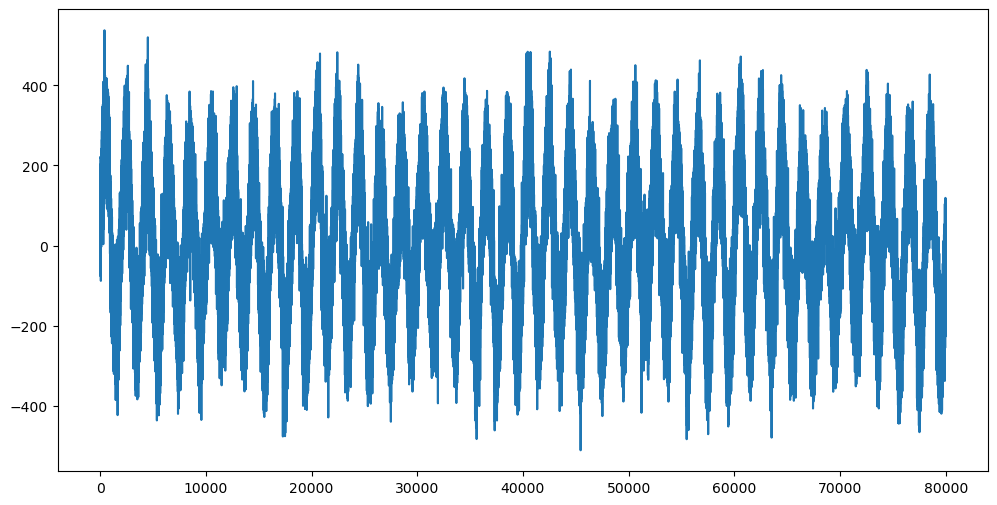

In [27]:
# ----------------------------------------------------------------------------
# 7. Generate signal and visualise
# ----------------------------------------------------------------------------
signal = generate_signal(t)
plt.figure(figsize=(12, 6))
plt.plot(signal)
len(signal)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Best Threshold Frequency:  0.005
Best R2 value:  0.8255987890463401

Regression Model Comparison

Metric                          DNN      Optimizer
--------------------------------------------------
RMSE                     100.102807      71.743592               28.359214584498574
MAE                       79.871165      57.250277               22.620888231062274
R2                         0.660472       0.825599               0.16512692623401526
MedAE                     67.755273      48.159103               19.596170428197624
ExplainedVariance          0.660475       0.825602               0.16512692623401515
MaxError                 451.114879     311.684494               139.43038438919785


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


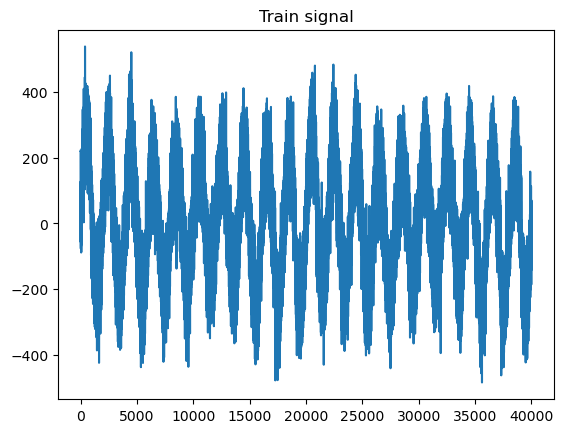

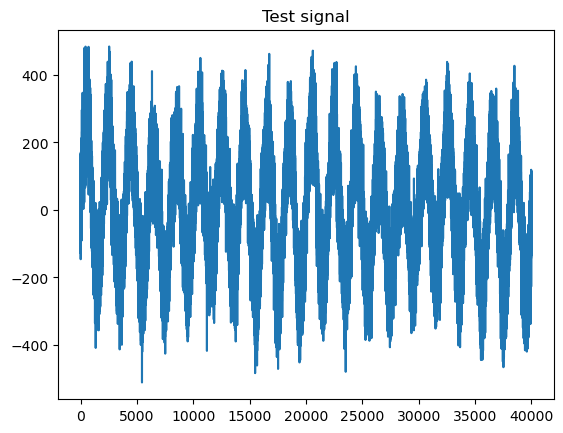

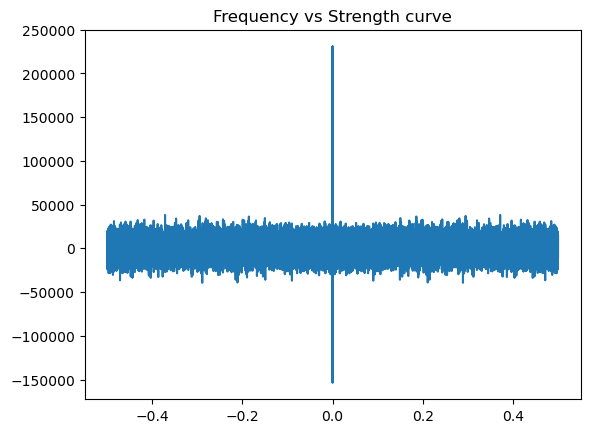

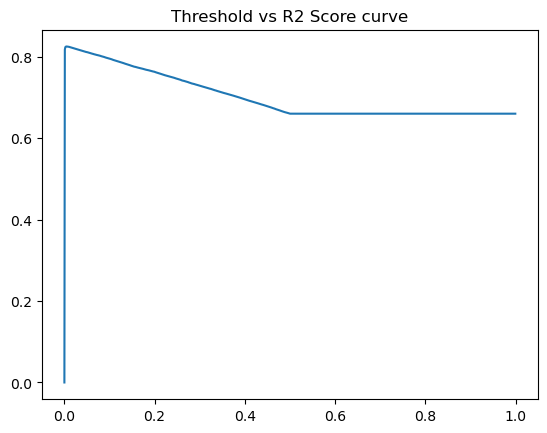

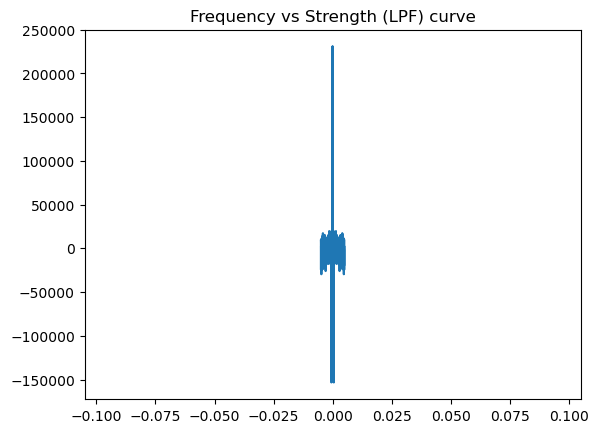

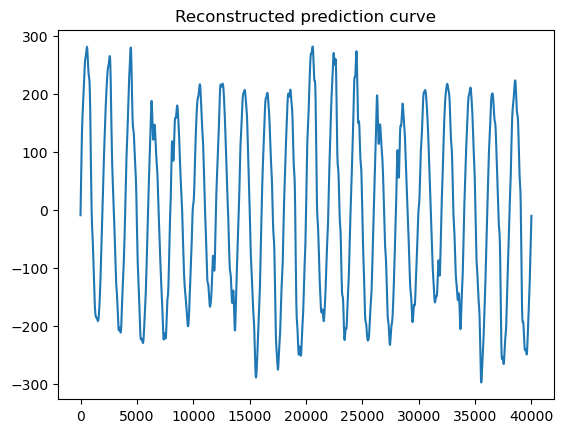

In [29]:
# ----------------------------------------------------------------------------
# 8. Run the blackbox FFT optimizer on the AR signal
# ----------------------------------------------------------------------------
analysis = blackbox(signal)